## Building a Patient Churn Prediction Model
This project was inspired by Karina Samsonova's latest tutorial on building a churn rate prediction model. Instead of following it exactly, I built a patient churn model instead of a customer churn model. 

I initially used a Kaggle-sourced patient churn dataset but found it had an unrealistic ~68% churn rate and no meaningful correlation between any feature and the Churned outcome. I recreated the synthetic dataset (no real patient information is used) with the same columns, but with intentional relationships between key features and churn probability.

This notebook covers:
- model training, threshold tuning, and evaluation
- feature importance validation (MDI vs permutation importance)
- revenue-at-risk calculation and prioritized outreach list

In [1]:
# Step 1 - Load and Explore the Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")

df = pd.read_csv('raw/patient_churn_dataset.csv')

print(df.shape) # 2,000 rows and 21 columns
print(df.head())
print(df.info())

# Check churn rate
print(df['Churned'].value_counts(normalize=True).round(3))

(2000, 21)
  PatientID  Age  Gender State  Tenure_Months   Specialty Insurance_Type  \
0        P1   69  Female    GA            107  Psychiatry       Medicaid   
1        P2   32    Male    PA             80  Psychiatry       Self-Pay   
2        P3   89    Male    DE            110  Pediatrics       Medicare   
3        P4   78  Female    DE             72   Neurology       Self-Pay   
4        P5   38  Female    TX             56  Psychiatry       Self-Pay   

   Visits_Last_Year  Missed_Appointments  Days_Since_Last_Visit  ...  \
0                14                    1                    285  ...   
1                14                    2                    453  ...   
2                 5                    3                    316  ...   
3                 8                    0                    589  ...   
4                 6                    3                    296  ...   

  Overall_Satisfaction  Wait_Time_Satisfaction  Staff_Satisfaction  \
0                  4.0       

The patient churn rate in this dataset is 23.1%.

Next step is to explore what is driving the churn rate.

In [2]:
# Step 2 - Explore the Dataset

# Before I do anything else, I will create a new column 'Age Range' to make it easier to evaluate if 'Age' \
# influences 'Churned'.

df['Age Range'] = pd.cut(df['Age'], bins=[17, 30, 45, 60, 75, 90], labels=['18-30', '31-45', '46-60', '61-75', '76-90'])

In [3]:
# Finding the correlation between numerical features and churn rate with a correlation matrix

numerical_features = df.select_dtypes(include='number')
corr_matrix = numerical_features.corr()
print(corr_matrix['Churned'].sort_values(ascending=False))

Churned                          1.000000
Billing_Issues                   0.338385
Distance_To_Facility_In_Miles    0.053528
Days_Since_Last_Visit            0.048956
Portal_Usage                     0.030869
Age                              0.024349
Tenure_Months                    0.014353
Avg_Out_Of_Pocket_Cost           0.010659
Wait_Time_Satisfaction           0.006558
Visits_Last_Year                 0.002412
Referrals_Made                   0.002055
Missed_Appointments             -0.017850
Provider_Rating                 -0.018390
Staff_Satisfaction              -0.028964
Overall_Satisfaction            -0.034188
Name: Churned, dtype: float64


Based on the correlation matrix, there is a 33.8% correlation between **Billing_Issues** and the churn rate.

In [4]:
# Finding the correlation between categorical features and churn rate with groupby and mean

# Gender and Churned
df.groupby('Gender')['Churned'].mean().sort_values(ascending=False)

Gender
Male      0.247012
Female    0.214859
Name: Churned, dtype: float64

Male has a 24.7% and Female, 21.5% correlation. Not enough distinction to have any influence on the churn rate.

In [5]:
# State and Churned
df.groupby('State')['Churned'].mean().sort_values(ascending=False)

State
TX    0.273743
GA    0.257732
DE    0.245989
PA    0.233766
IL    0.229508
CA    0.228856
NJ    0.223881
MD    0.218605
FL    0.203791
NY    0.202020
Name: Churned, dtype: float64

In [6]:
# Applying a Chi-Square test to further test a possible correlation between State and Churned

from scipy.stats import chi2_contingency

chi2_stat, p_value, dof, expected = chi2_contingency(pd.crosstab(df['State'], df['Churned']))
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-Value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:\n", expected)

if p_value < 0.05:
    print("There is a significant association between State and Churned.")
else:
    print("There is no significant association between State and Churned.")

Chi-Square Statistic: 4.9341
P-Value: 0.8400
Degrees of Freedom: 9
Expected Frequencies:
 [[154.569  46.431]
 [143.803  43.197]
 [162.259  48.741]
 [149.186  44.814]
 [140.727  42.273]
 [165.335  49.665]
 [154.569  46.431]
 [152.262  45.738]
 [177.639  53.361]
 [137.651  41.349]]
There is no significant association between State and Churned.


Using groupby revealed percentages too close together. Not enough distinction to have any influence on the churn rate. Further testing with the chi-square testing also shows there is no significant association between State and Churned.

In [7]:
# Specialty and Churned
df.groupby('Specialty')['Churned'].mean().sort_values(ascending=False)

Specialty
Oncology           0.270677
Pediatrics         0.248252
Neurology          0.240283
Cardiology         0.231579
Psychiatry         0.227437
Dermatology        0.226115
Family Medicine    0.176471
Name: Churned, dtype: float64

In [8]:
chi2_stat, p_value, dof, expected = chi2_contingency(pd.crosstab(df['Specialty'], df['Churned']))
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-Value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:\n", expected)

if p_value < 0.05:
    print("There is a significant association between Specialty and Churned.")
else:
    print("There is no significant association between Specialty and Churned.")

Chi-Square Statistic: 7.8738
P-Value: 0.2475
Degrees of Freedom: 6
Expected Frequencies:
 [[219.165  65.835]
 [241.466  72.534]
 [222.241  66.759]
 [217.627  65.373]
 [204.554  61.446]
 [219.934  66.066]
 [213.013  63.987]]
There is no significant association between Specialty and Churned.


Like State and Churned, groupby and chi-square testing revealed that there is no significant association between Specialty and Churned.

In [9]:
# Insurance_Type and Churned
df.groupby('Insurance_Type')['Churned'].mean().sort_values(ascending=False)

Insurance_Type
Self-Pay    0.318750
Medicaid    0.223629
Private     0.199630
Medicare    0.188119
Name: Churned, dtype: float64

In [10]:
chi2_stat, p_value, dof, expected = chi2_contingency(pd.crosstab(df['Insurance_Type'], df['Churned']))
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-Value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:\n", expected)

if p_value < 0.05:
    print("There is a significant association between Insurance_Type and Churned.")
else:
    print("There is no significant association between Insurance_Type and Churned.")

Chi-Square Statistic: 29.1758
P-Value: 0.0000
Degrees of Freedom: 3
Expected Frequencies:
 [[364.506 109.494]
 [388.345 116.655]
 [416.029 124.971]
 [369.12  110.88 ]]
There is a significant association between Insurance_Type and Churned.


After correlation and association testing, it appears that **Insurance_Type**, especially Self-Pay, has a significant association with the churn rate.

In [11]:
# Step 3 - Prepare the Data for Modeling

# Drop PatientID - it is just an identifier and does not provide any predictive value
# Drop Age Range - it is derived from Age and will not provide any additional predictive value
df.drop('PatientID', axis=1, inplace=True)
df.drop('Age Range', axis=1, inplace=True)

# Encode categorical variables using Label Encoding
cat_cols = df.select_dtypes(include='str').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# This dataset contains no missing values, so no additional cleaning is necessary.
# But it is good practice to always check.
if df.isnull().sum().sum() > 0:
    df = df.dropna()  # Drop rows with missing values

In [12]:
# Step 4 - Build the Model

X = df.drop('Churned', axis=1)
y = df['Churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

model = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1 # use all CPU cores
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] # churn probability per patient

              precision    recall  f1-score   support

      Stayed       0.82      0.86      0.84       308
     Churned       0.45      0.38      0.41        92

    accuracy                           0.75       400
   macro avg       0.64      0.62      0.63       400
weighted avg       0.74      0.75      0.74       400



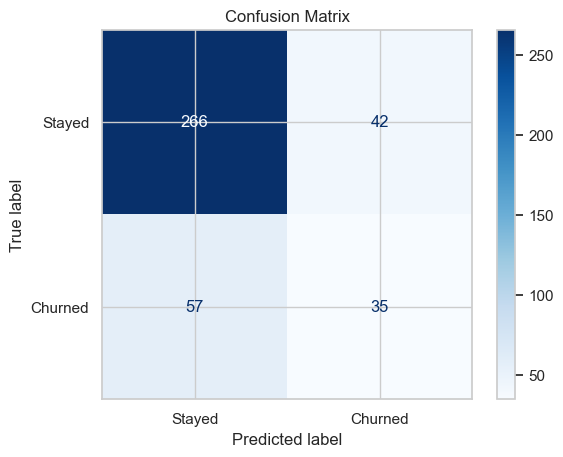

In [13]:
# Step 5 - Evaluate the Model
threshold = 0.30 #adjusting the threshold to 0.30 to increase sensitivity and capture more potential churners
y_pred_adj = (y_prob >= threshold).astype(int)

print(classification_report(y_test, y_pred_adj, target_names=['Stayed', 'Churned']))

cm = confusion_matrix(y_test, y_pred_adj)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [14]:
# Step 6 - The Business Layer: Revenue at Risk

results = X_test.copy()
results['Churn_Actual'] = y_test.values
results['Churn_Probability'] = y_prob
results['Annual_Revenue'] = results['Avg_Out_Of_Pocket_Cost'] * results['Visits_Last_Year']
results['Monthly_Revenue'] = results['Annual_Revenue'] / 12

# Expected monthly revenue at risk = probability of churn * average out-of-pocket cost
results['Revenue_at_Risk'] = results['Churn_Probability'] * results['Monthly_Revenue']

# Sort by Revenue at Risk - Highest Priority First
results = results.sort_values(by='Revenue_at_Risk', ascending=False)

# Total Revenue at Risk
total_at_risk = results['Revenue_at_Risk'].sum()
print(f"Total Monthly Revenue at Risk: ${total_at_risk:,.2f}")

# Top 20 patients to contact first
top_20 = results[['Churn_Probability', 'Monthly_Revenue', 'Revenue_at_Risk']].head(20)
print(top_20)

#

Total Monthly Revenue at Risk: $52,015.36
      Churn_Probability  Monthly_Revenue  Revenue_at_Risk
1984               0.61      1916.378333      1168.990783
248                0.61      1537.873333       938.102733
1828               0.61      1350.265000       823.661650
320                0.39      1900.930000       741.362700
1724               0.50      1434.323333       717.161667
1922               0.31      1988.140000       616.323400
268                0.47      1249.606667       587.315133
1091               0.60       965.323333       579.194000
1836               0.26      2132.865000       554.544900
15                 0.44      1258.840000       553.889600
1124               0.61       894.160000       545.437600
1916               0.62       872.316667       540.836333
720                0.48      1120.038333       537.618400
96                 0.66       809.715833       534.412450
132                0.56       945.070000       529.239200
1849               0.35      1

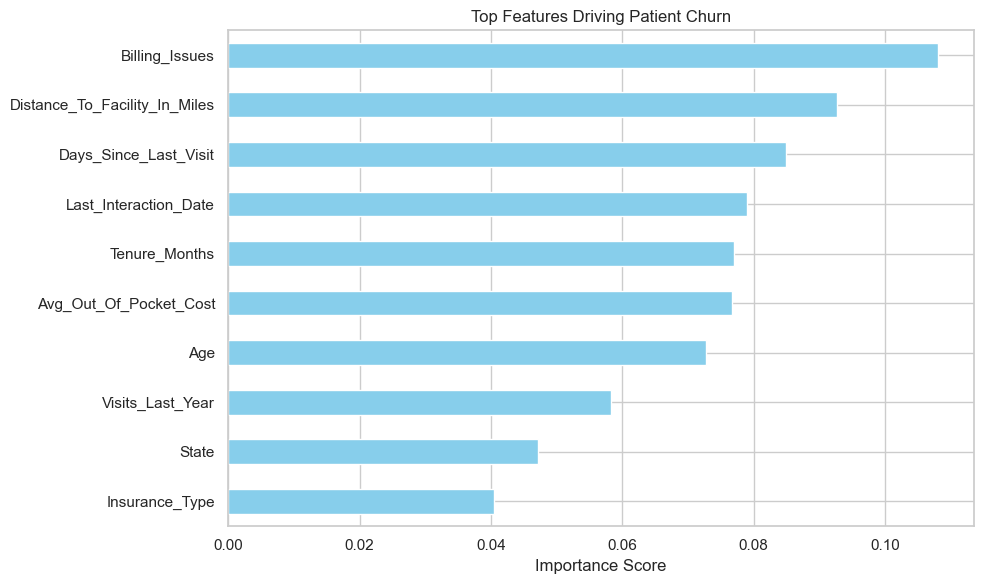

In [15]:
# Step 7 - Feature Importance

importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

top_features.plot(kind='barh', figsize=(10, 6), color='skyblue')
plt.title('Top Features Driving Patient Churn')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest importance at the top
plt.tight_layout()
plt.show()

According to this bar chart, **Billing_Issues** is a significant feature in influencing the churn rate, followed by **Distance_To_Facility_In_Miles**. However, why are **Last_Interaction_Date** and **Days_Since_Last_Interaction** so close together near the top? Further investigation needs to be done.

In [16]:
# Investigating if there is a correlation between 'Last_Interaction_Date' and 'Days_Since_Last_Interaction_Numeric'

df['Last_Interaction_Date'] = pd.to_datetime(df['Last_Interaction_Date'])
reference_date = pd.to_datetime('2024-01-01')
df['Days_Since_Last_Interaction_Numeric'] = (reference_date - df['Last_Interaction_Date']).dt.days
print(df[['Last_Interaction_Date', 'Days_Since_Last_Interaction_Numeric']].corr())

                                     Last_Interaction_Date  \
Last_Interaction_Date                             1.000000   
Days_Since_Last_Interaction_Numeric              -0.067599   

                                     Days_Since_Last_Interaction_Numeric  
Last_Interaction_Date                                          -0.067599  
Days_Since_Last_Interaction_Numeric                             1.000000  


No correlation appears to exist between the two. Further testing with permutation importance.

In [17]:
# Comparing Feature Importance with Permutation Importance using ROC AUC as the scoring metric

from sklearn.inspection import permutation_importance

perm_result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1, scoring='roc_auc')

perm_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_result.importances_mean
}).sort_values(by='Importance', ascending=False)

print(perm_df)

                          Feature  Importance
15                 Billing_Issues    0.143796
3                   Tenure_Months    0.020979
18  Distance_To_Facility_In_Miles    0.014055
5                  Insurance_Type    0.013492
10           Overall_Satisfaction    0.012054
12             Staff_Satisfaction    0.008307
7             Missed_Appointments    0.007453
1                          Gender    0.004565
9           Last_Interaction_Date    0.003060
16                   Portal_Usage    0.002874
11         Wait_Time_Satisfaction    0.000641
8           Days_Since_Last_Visit   -0.000607
4                       Specialty   -0.002193
17                 Referrals_Made   -0.005027
0                             Age   -0.005320
6                Visits_Last_Year   -0.006409
2                           State   -0.009169
13                Provider_Rating   -0.010585
14         Avg_Out_Of_Pocket_Cost   -0.013081


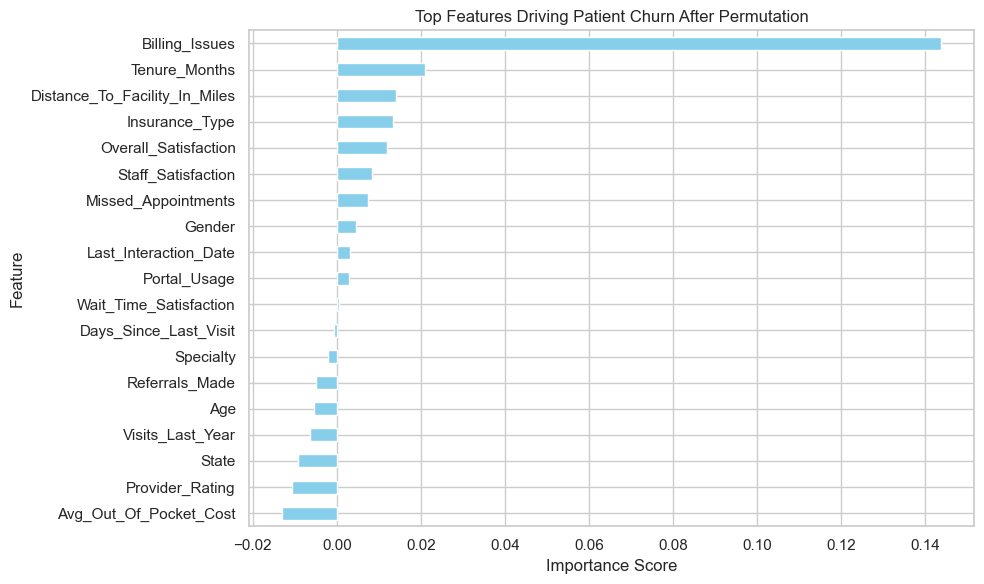

In [19]:
perm_df.set_index('Feature')['Importance'].plot(kind='barh', figsize=(10, 6), color='skyblue')
plt.title('Top Features Driving Patient Churn After Permutation')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest importance at the top
plt.tight_layout()
plt.show()

ROC-AUC-scored permutation importance resolves the earlier contradiction. 

**Billing_Issues**, **Distance_To_Facility_In_Miles**, **Insurance_Type**, and **Overall_Satisfaction** (the designed drivers) show positive importance, while the two known-noise columns (Days_Since_Last_Visit, Last_Interaction_Date, r=0.067) correctly drop to near-zero. Accuracy-scored permutation importance had missed this due to threshold insensitivity.